In [2]:
!pip install gradio psutil pandas plotly nvidia-ml-py requests

In [3]:
import gradio as gr
import psutil
import pandas as pd
import plotly.graph_objects as go
import requests

from pynvml import *

print("Everything imported successfully.")

Everything imported successfully.


In [4]:
from pynvml import *

nvmlInit()

print("Driver:", nvmlSystemGetDriverVersion())

print("GPU Count:", nvmlDeviceGetCount())

for i in range(nvmlDeviceGetCount()):
    h = nvmlDeviceGetHandleByIndex(i)
    print(i, nvmlDeviceGetName(h))

nvmlShutdown()

Driver: 580.105.08
GPU Count: 8
0 NVIDIA A100-SXM4-80GB
1 NVIDIA A100-SXM4-80GB
2 NVIDIA A100-SXM4-80GB
3 NVIDIA A100-SXM4-80GB
4 NVIDIA A100-SXM4-80GB
5 NVIDIA A100-SXM4-80GB
6 NVIDIA A100-SXM4-80GB
7 NVIDIA A100-SXM4-80GB


In [5]:
from gpu import get_gpu_info

import pandas as pd

pd.DataFrame(get_gpu_info())

,GPU,Name,Memory Used (GB),Memory Total (GB),GPU Util (%),Memory Util (%),Temperature,Power (W)
0,0,NVIDIA A100-SXM4-80GB,79.83,80.0,0,0,37,70.6
1,1,NVIDIA A100-SXM4-80GB,1.86,80.0,0,0,38,86.2
2,2,NVIDIA A100-SXM4-80GB,1.20,80.0,0,0,39,87.4
3,3,NVIDIA A100-SXM4-80GB,0.75,80.0,0,0,35,66.2
4,4,NVIDIA A100-SXM4-80GB,0.75,80.0,0,0,37,62.9
5,5,NVIDIA A100-SXM4-80GB,1.23,80.0,0,0,39,91.8
6,6,NVIDIA A100-SXM4-80GB,0.75,80.0,0,0,37,81.6
7,7,NVIDIA A100-SXM4-80GB,1.23,80.0,0,0,39,115.8


In [6]:
from processes import get_gpu_processes
import pandas as pd

pd.DataFrame(get_gpu_processes())

,GPU,PID,Student,GPU Memory (MB),CPU %,RAM (MB),User,Executable,Working Directory,Command
0,0,3704211,23BRS1236,80546.0,0.0,2067.9,nvidia,/home/nvidia/.local/share/uv/python/cpython-3....,/lp-dev/23BRS1236/mnt/ADHD200/RawDataBIDS,/home/nvidia/.venv/bin/python3 -m ipykernel_la...
1,0,85462,23BRS1123,418.0,0.0,2322.9,nvidia,/home/nvidia/miniconda_311/bin/python3.13,/home/nvidia/23BRS1123/project_test_2/project_...,/home/nvidia/23BRS1123/honeycomb_env/bin/pytho...
2,1,1736136,21PHD1192,454.0,0.0,1102.8,nvidia,/home/nvidia/miniconda_311/envs/quantum311/bin...,/home/nvidia/21PHD1192/qml_id2/UNSW_code,/home/nvidia/miniconda_311/envs/quantum311/bin...
3,1,3264039,23BRS1236,664.0,0.0,2766.3,nvidia,/home/nvidia/.local/share/uv/python/cpython-3....,/home/nvidia/23BRS1236,/home/nvidia/.venv/bin/python3 -m ipykernel_la...
4,2,1736276,21PHD1192,454.0,0.0,1116.9,nvidia,/home/nvidia/miniconda_311/envs/quantum311/bin...,/home/nvidia/21PHD1192/qml_id2/UNSW_code,/home/nvidia/miniconda_311/envs/quantum311/bin...
5,5,1028910,21PHD1192,488.0,0.0,1146.3,nvidia,/home/nvidia/miniconda_311/envs/quantum311/bin...,/home/nvidia/21PHD1192/qml_id2/UNSW_code,/home/nvidia/miniconda_311/envs/quantum311/bin...
6,7,1029443,21PHD1192,488.0,0.0,1144.5,nvidia,/home/nvidia/miniconda_311/envs/quantum311/bin...,/home/nvidia/21PHD1192/qml_id2/UNSW_code,/home/nvidia/miniconda_311/envs/quantum311/bin...


In [1]:
from jupyter_utils import get_running_kernels
import pandas as pd

pd.DataFrame(get_running_kernels())

,Kernel ID,Kernel Name,Execution State,Notebook,Type
0,ccde8ed3-c000-4517-9fcc-ce801703a83e,python3,idle,23BRS1236/w2b_population_graph_learning.ipynb,notebook
1,8de2646f-0a5c-40a1-9b61-1ff147642660,myenv,idle,24MDT1073/FMRICNN.ipynb,notebook
2,afde23f9-4b9c-4bdf-ae85-43a9c3f86f6d,myenv,idle,24MDT1073/QCNN_V3.ipynb,notebook
3,5280c70c-6c17-43d6-a7d7-d3336e02b237,myenv,idle,24MDT1073/SMRICNN.ipynb,notebook
4,a5efc51d-a4f8-40a9-b27a-a3fb2a574b65,python3,idle,23BRS1236/mnt/ADHD200/RawDataBIDS/part1.ipynb,notebook
5,e33a2986-4e08-467a-8f8d-2c9fa50e7e38,python3,idle,23BRS1236/w2c_dann.ipynb,notebook
6,0a332564-69c4-4014-9bd5-85568fec48d6,python3,idle,23BRS1236/mnt/ADHD200/RawDataBIDS/part1.ipynb,notebook
7,62032930-8323-4468-8290-a71d11353392,myenv,idle,23BRS1236/neuro.ipynb,notebook
8,d3ac58ba-b293-4f18-98de-f9d0cdeb24f9,python3,idle,23BRS1236/nb1_baseline.ipynb,notebook
9,48f49b69-2d03-4a94-969b-aee17ce73645,honeycomb_env,idle,23BRS1123/project_test_2/project_test_2/projec...,notebook


In [2]:
from gpu import get_gpu_info
from history import add_snapshot, get_history

import pandas as pd

gpu_df = pd.DataFrame(get_gpu_info())

add_snapshot(gpu_df)

pd.DataFrame(get_history())

/home/nvidia/server_dashboard/gpu.py:1: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import *


,Time,GPU,GPU Util (%),Memory Used (GB)
0,07:17:29,0,0,79.83
1,07:17:29,1,0,1.86
2,07:17:29,2,0,1.20
3,07:17:29,3,0,0.75
4,07:17:29,4,0,0.75
5,07:17:29,5,0,1.23
6,07:17:29,6,0,0.75
7,07:17:29,7,0,1.23


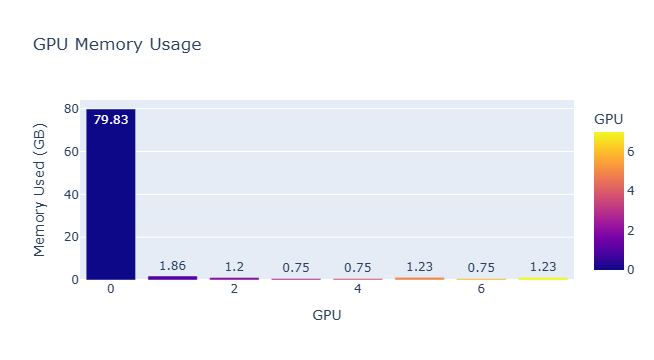

In [3]:
from monitor import gpu_memory_chart

gpu_memory_chart()

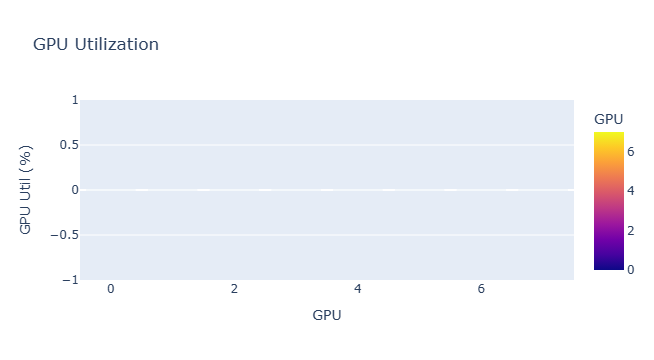

In [4]:
from monitor import gpu_util_chart

gpu_util_chart()

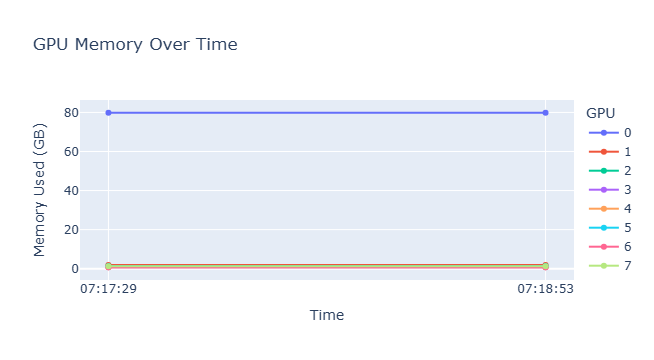

In [5]:
from monitor import history_chart

history_chart()